## Import Libraries

In [36]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import models, layers, optimizers
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, confusion_matrix
import seaborn as sns
import json
import joblib
from tensorflow.keras.callbacks import EarlyStopping

## 1. Dataset Manipulation

### 1.1 Load dataset

In [2]:
SIZE = 64
image_directory = "malaria_dataset/"

dataset = [] # images
label = []   # labels

# Load Parasitized Images → label 1
parasitized_images = os.listdir(image_directory + "Parasitized/")

for image_name in parasitized_images:
    if image_name.endswith(".png"):
        image = cv2.imread(image_directory + "Parasitized/" + image_name)
        image = Image.fromarray(image, "RGB")
        image = image.resize((SIZE, SIZE))
        dataset.append(np.array(image))
        label.append(1)

# Load Uninfected Images → label 0
uninfected_images = os.listdir(image_directory + "Uninfected/")

for image_name in uninfected_images:
    if image_name.endswith(".png"):
        image = cv2.imread(image_directory + "Uninfected/" + image_name)
        image = Image.fromarray(image, "RGB")
        image = image.resize((SIZE, SIZE))
        dataset.append(np.array(image))
        label.append(0)

dataset = np.array(dataset)
label = np.array(label)

print("Dataset shape:", dataset.shape)
print("Labels shape:", label.shape)

Dataset shape: (1067, 64, 64, 3)
Labels shape: (1067,)


### 1.2 Plot Images

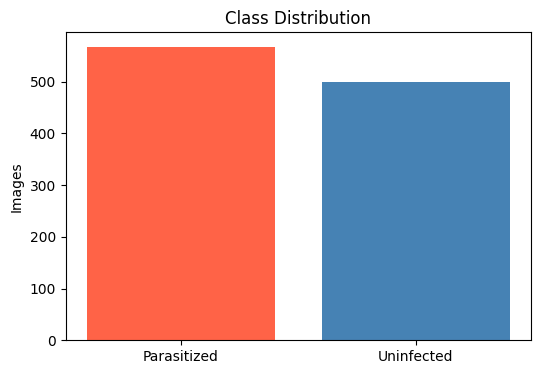

Parasitized: 500 images
Uninfected:  567 images
Total:       1067 images


In [3]:
# Class Distribution
unique, counts = np.unique(label, return_counts=True)

class_names = ["Parasitized", "Uninfected"]

plt.figure(figsize=(6, 4))
plt.bar(class_names, counts, color=["tomato", "steelblue"])

plt.title("Class Distribution")
plt.ylabel("Images")
plt.show()

print(f"Parasitized: {counts[1]} images")
print(f"Uninfected:  {counts[0]} images")
print(f"Total:       {len(label)} images")


### 1.3 Slipt and Normalization

In [4]:
# Normalization
dataset = dataset / 255.0

# One-hot encoding
label_cat = to_categorical(label, num_classes=2)

# train (80) / test (20) Split
X_train, X_test, y_train, y_test = train_test_split(
    dataset,
    label_cat,
    test_size=0.20,
    random_state=42,
    stratify=label  # Same as the orignal data
)

# train (80) / validation (20) Split
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (682, 64, 64, 3)
X_val shape:   (171, 64, 64, 3)
X_test shape:  (214, 64, 64, 3)


## 2. Feed Forward (FFN)

### 2.1 Define the model

In [5]:
model_ffn = models.Sequential(name="Feed_Forward_Network")

# Input Layer: 64x64x3 → 12288
model_ffn.add(layers.Flatten(input_shape=(SIZE, SIZE, 3)))

# Hidden Layer 1: 256 neurons + Dropout
model_ffn.add(layers.Dense(256, activation='relu'))
model_ffn.add(layers.Dropout(0.3))

# Hidden Layer 2: 128 neurons + Dropout
model_ffn.add(layers.Dense(128, activation='relu'))
model_ffn.add(layers.Dropout(0.3))

# Hidden Layer 3: 64 neurons
model_ffn.add(layers.Dense(64, activation='relu'))

# Output Layer: 2 neurons (Parasitized / Uninfected)
model_ffn.add(layers.Dense(2, activation='softmax'))

model_ffn.summary()

/home/chickenux/Documents/celulas_clasificacion/ambientexd/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1776238941.384334  137917 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776238941.384588  138144 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776238941.403728  137917 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU

Model: "Feed_Forward_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,266 (12.16 MB)

 Trainable params: 3,187,266 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Compile and Fit

In [6]:
# Compile
model_ffn.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Fit
history_ffn = model_ffn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val)
)

# Guardar pesos igual que el profe
model_ffn.save_weights('M1_FNN.weights.h5')

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4824 - auc: 0.4871 - loss: 1.8726 - precision: 0.4824 - val_accuracy: 0.5731 - val_auc: 0.5926 - val_loss: 0.6833 - val_precision: 0.5731
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5469 - auc: 0.5562 - loss: 1.0163 - precision: 0.5469 - val_accuracy: 0.4737 - val_auc: 0.4801 - val_loss: 0.7130 - val_precision: 0.4737
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5103 - auc: 0.5124 - loss: 0.8007 - precision: 0.5103 - val_accuracy: 0.5088 - val_auc: 0.5558 - val_loss: 0.6982 - val_precision: 0.5088
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5308 - auc: 0.5378 - loss: 0.7276 - precision: 0.5308 - val_accuracy: 0.6550 - val_auc: 0.7486 - val_loss: 0.6394 - val_precision: 0.6550
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5616 - auc: 0.5990 - loss: 0.6805 - precision: 0.5616 - val_accuracy: 0.6901 - val_auc: 0.7716 - val_loss: 0.6162 - val_pre

### 2.3 Training Curves

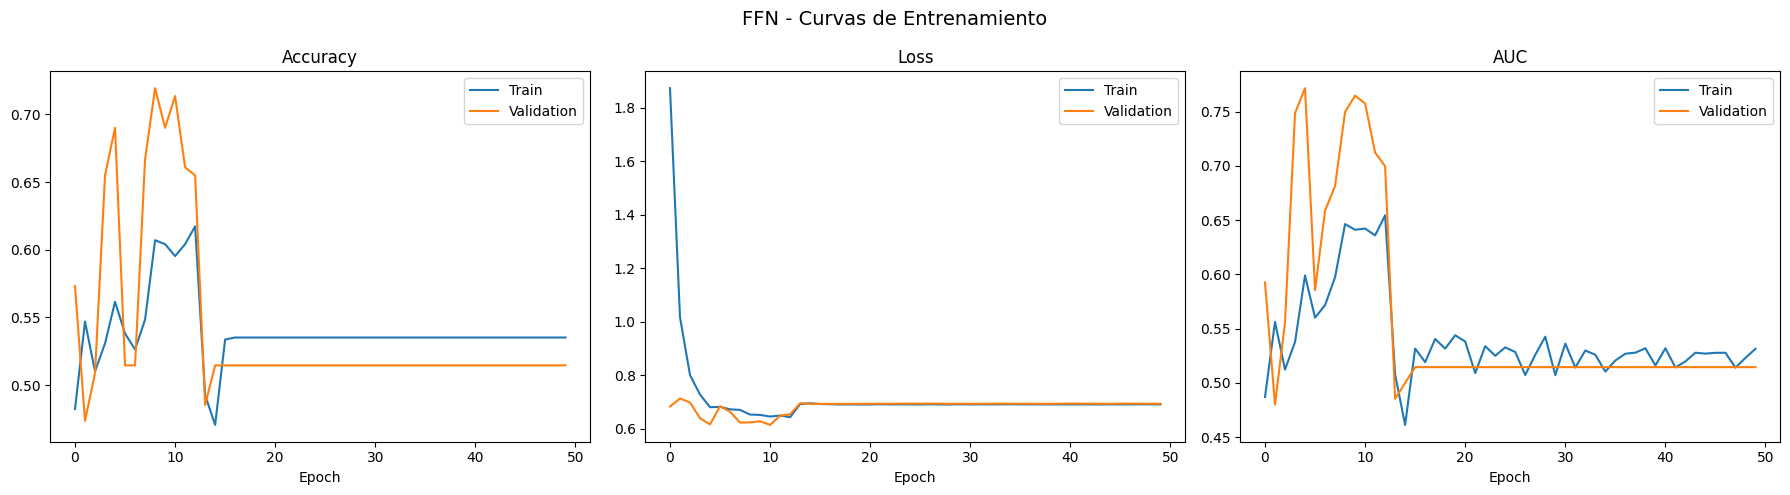

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("FFN - Curvas de Entrenamiento", fontsize=14)

axes[0].plot(history_ffn.history['accuracy'], label='Train')
axes[0].plot(history_ffn.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_ffn.history['loss'], label='Train')
axes[1].plot(history_ffn.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_ffn.history['auc'], label='Train')
axes[2].plot(history_ffn.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Convolutional Neural Network (CNN)

### 3.1 Define the model

In [8]:
model_cnn = models.Sequential(name="CNN")


model_cnn.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(SIZE, SIZE, 3)))
model_cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(layers.Dropout(0.2))


model_cnn.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(layers.Dropout(0.2))

model_cnn.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(layers.Dropout(0.2))

# Classifier
model_cnn.add(layers.Flatten())
model_cnn.add(layers.Dense(128, activation='relu'))
model_cnn.add(layers.Dropout(0.3))

# Output, 2 classes
model_cnn.add(layers.Dense(2, activation='softmax'))

model_cnn.summary()

/home/chickenux/Documents/celulas_clasificacion/ambientexd/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,458 (2.61 MB)

 Trainable params: 683,458 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Compile and Fit

In [9]:
model_cnn.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

model_cnn.save_weights('M2_CNN.weights.h5')

Epoch 1/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5235 - auc: 0.5410 - loss: 0.7120 - precision: 0.5235 - val_accuracy: 0.5146 - val_auc: 0.5419 - val_loss: 0.6933 - val_precision: 0.5146
Epoch 2/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5191 - auc: 0.5467 - loss: 0.6916 - precision: 0.5191 - val_accuracy: 0.5146 - val_auc: 0.4597 - val_loss: 0.6960 - val_precision: 0.5146
Epoch 3/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5557 - auc: 0.5554 - loss: 0.6893 - precision: 0.5557 - val_accuracy: 0.5146 - val_auc: 0.6002 - val_loss: 0.6873 - val_precision: 0.5146
Epoch 4/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5806 - auc: 0.5830 - loss: 0.6848 - precision: 0.5806 - val_accuracy: 0.6374 - val_auc: 0.7241 - val_loss: 0.6650 - val_precision: 0.6374
Epoch 5/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6452 - auc: 0.6668 - loss: 0.6560 - precision: 0.6452 - val_accuracy: 0.7018 - val_auc: 0.8019 - val_loss: 0.6345 - val_pre

### 3.3 Training Curves

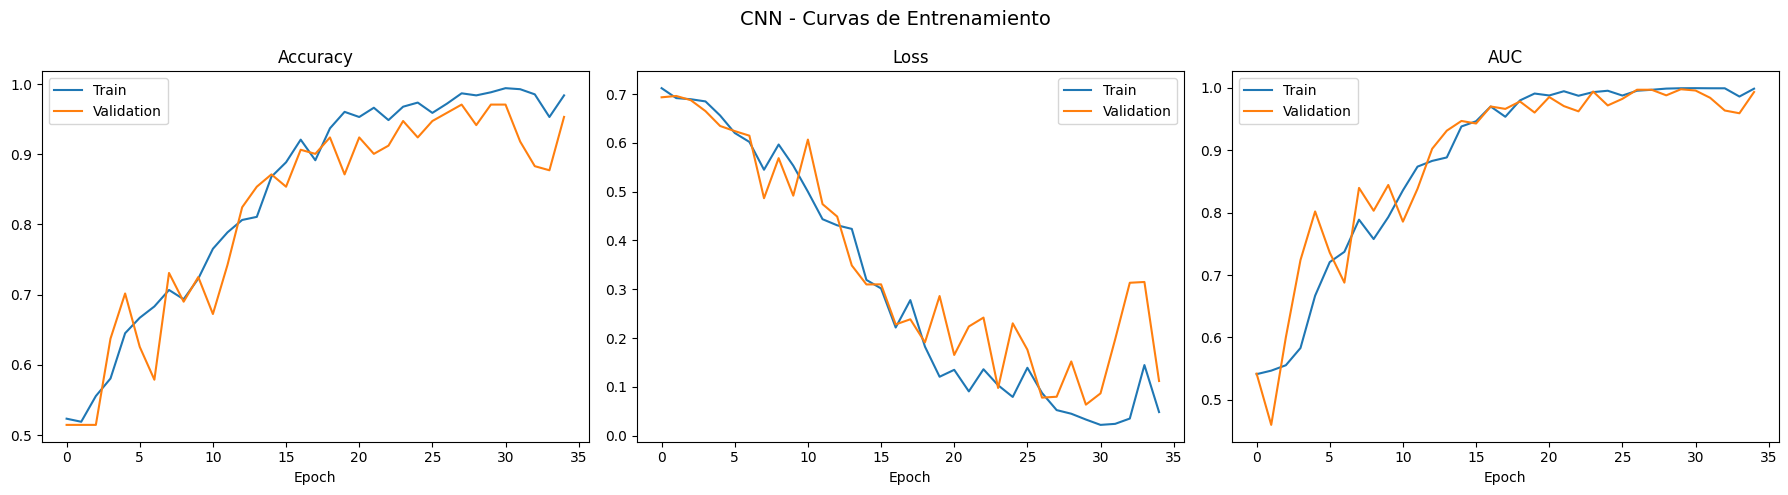

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CNN - Curvas de Entrenamiento", fontsize=14)

axes[0].plot(history_cnn.history['accuracy'], label='Train')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_cnn.history['loss'], label='Train')
axes[1].plot(history_cnn.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_cnn.history['auc'], label='Train')
axes[2].plot(history_cnn.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. CNN with Data Augmentation

### 4.1 Data Augmentation

In [27]:
# Augmentation solo para train
train_datagen = ImageDataGenerator(
    rotation_range=10,        # Rota la imagen hasta 10°
    width_shift_range=0.05,    # Desplaza horizontalmente hasta 5%
    height_shift_range=0.05,   # Desplaza verticalmente hasta 5%
    zoom_range=0.05,           # Zoom hasta 5%
    horizontal_flip=True,     # Flip horizontal aleatorio
)

# Validation y Test -> No augmentation
val_datagen = ImageDataGenerator()

### 4.2 Define the Model

In [28]:
model_cnn_aug = models.Sequential(name="CNN_Aug")

# Bloque 1
model_cnn_aug.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(SIZE, SIZE, 3)))
model_cnn_aug.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug.add(layers.Dropout(0.2))

# Bloque 2
model_cnn_aug.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_cnn_aug.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug.add(layers.Dropout(0.2))

# Bloque 3
model_cnn_aug.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_cnn_aug.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug.add(layers.Dropout(0.2))

# Clasificador
model_cnn_aug.add(layers.Flatten())
model_cnn_aug.add(layers.Dense(128, activation='relu'))
model_cnn_aug.add(layers.Dropout(0.3))

# Salida
model_cnn_aug.add(layers.Dense(2, activation='softmax'))

model_cnn_aug.summary()

Model: "CNN_Aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,458 (2.61 MB)

 Trainable params: 683,458 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

### 4.3 Compile and Fit

In [29]:
model_cnn_aug.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)


# Generadores
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)


history_cnn_aug = model_cnn_aug.fit(
    train_generator,
    epochs=60,
    validation_data=val_generator,
    callbacks=[early_stop]
)

# Guardar pesos
model_cnn_aug.save_weights('M3_CNN_aug.weights.h5')

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5235 - auc: 0.5442 - loss: 0.7317 - precision: 0.5235 - val_accuracy: 0.5146 - val_auc: 0.5217 - val_loss: 0.6925 - val_precision: 0.5146
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5484 - auc: 0.5619 - loss: 0.6896 - precision: 0.5484 - val_accuracy: 0.5146 - val_auc: 0.6336 - val_loss: 0.6900 - val_precision: 0.5146
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5176 - auc: 0.5792 - loss: 0.6845 - precision: 0.5176 - val_accuracy: 0.5146 - val_auc: 0.6335 - val_loss: 0.6857 - val_precision: 0.5146
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5894 - auc: 0.6483 - loss: 0.6578 - precision: 0.5894 - val_accuracy: 0.4854 - val_auc: 0.6099 - val_loss: 0.7081 - val_precision: 0.4854
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5103 - auc: 0.5937 - loss: 0.6662 - precision: 0.5103 - val_accuracy: 0.5439 - val_auc: 0.6615 - val_loss: 0.6351 - val_pre

### 4.4 Training Curves

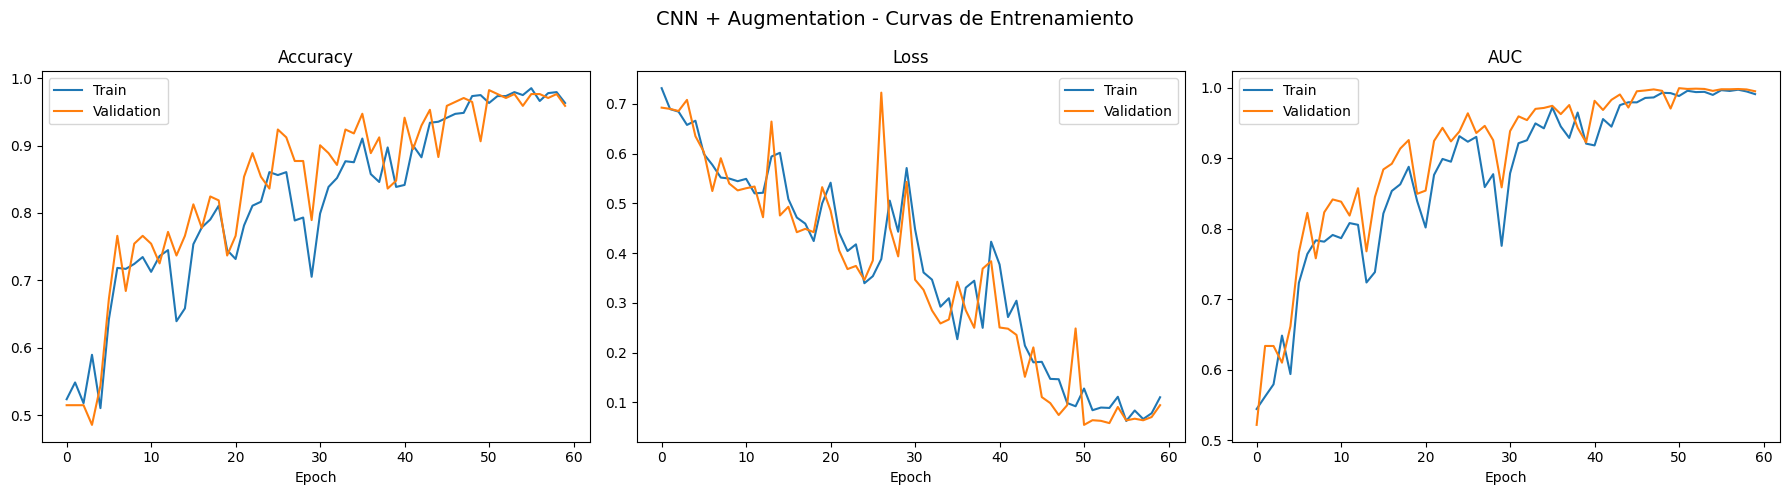

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CNN + Augmentation - Curvas de Entrenamiento", fontsize=14)

axes[0].plot(history_cnn_aug.history['accuracy'], label='Train')
axes[0].plot(history_cnn_aug.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_cnn_aug.history['loss'], label='Train')
axes[1].plot(history_cnn_aug.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_cnn_aug.history['auc'], label='Train')
axes[2].plot(history_cnn_aug.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Pretrained Architecture as a Feature Extractor (Machine Learning)

### 5.1 Preparing the Data

In [31]:
# VGG16 use 224x224 images and self preprocess_input
SIZE_VGG = 224


dataset_vgg = []
label_vgg = []

# Parasitized → label 1
for image_name in parasitized_images:
    if image_name.endswith(".png"):
        img = cv2.imread(image_directory + "Parasitized/" + image_name)
        img = cv2.resize(img, (SIZE_VGG, SIZE_VGG))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        dataset_vgg.append(img)
        label_vgg.append(1)

# Uninfected → label 0
for image_name in uninfected_images:
    if image_name.endswith(".png"):
        img = cv2.imread(image_directory + "Uninfected/" + image_name)
        img = cv2.resize(img, (SIZE_VGG, SIZE_VGG))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        dataset_vgg.append(img)
        label_vgg.append(0)

dataset_vgg = np.array(dataset_vgg)
label_vgg = np.array(label_vgg)

print("Dataset VGG shape:", dataset_vgg.shape)

Dataset VGG shape: (1067, 224, 224, 3)


### 5.2 Split Data

In [32]:
X_train_vgg, X_test_vgg, y_train_vgg, y_test_vgg = train_test_split(
    dataset_vgg, label_vgg,
    test_size=0.20,
    random_state=42,
    stratify=label_vgg
)

X_train_vgg, X_val_vgg, y_train_vgg, y_val_vgg = train_test_split(
    X_train_vgg, y_train_vgg,
    test_size=0.20,
    random_state=42
)

# Specific preprosessing
X_train_vgg = preprocess_input(X_train_vgg.astype('float32'))
X_val_vgg   = preprocess_input(X_val_vgg.astype('float32'))
X_test_vgg  = preprocess_input(X_test_vgg.astype('float32'))

print("X_train_vgg:", X_train_vgg.shape)
print("X_val shape:  ", X_val_vgg.shape)
print("X_test_vgg: ", X_test_vgg.shape)

X_train_vgg: (682, 224, 224, 3)
X_val shape:   (171, 224, 224, 3)
X_test_vgg:  (214, 224, 224, 3)


### 5.3 Define the Model

In [33]:
# include_top=False → remove final dense layers
VGG_model = VGG16(weights='imagenet', include_top=False, input_shape=(SIZE_VGG, SIZE_VGG, 3))

# Freeze weights
for layer in VGG_model.layers:
    layer.trainable = False

VGG_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### 5.4 Extract features

In [34]:
# train features
features_train = VGG_model.predict(X_train_vgg)
X_for_RF = features_train.reshape(features_train.shape[0], -1) #(n, 7, 7, 512) → (n, 25088)
print("Features train shape:", X_for_RF.shape)

# test features
features_test = VGG_model.predict(X_test_vgg)
X_test_RF = features_test.reshape(features_test.shape[0], -1)
print("Features test shape: ", X_test_RF.shape)

# val features
features_val = VGG_model.predict(X_val_vgg)
X_val_RF = features_val.reshape(features_val.shape[0], -1)
print("Features val shape:  ", X_val_RF.shape)

W0000 00:00:1776241252.400565  137917 cpu_allocator_impl.cc:82] Allocation of 410640384 exceeds 10% of free system memory.
W0000 00:00:1776241252.799741  137917 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267584 bytes after encountering the first element of size 19267584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1776241253.010837  138163 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.
W0000 00:00:1776241253.218550  138163 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.
W0000 00:00:1776241253.949163  138163 cpu_allocator_impl.cc:82] Allocation of 205520896 exceeds 10% of free system memory.
W0000 00:00:1776241254.104440  138163 cpu_allocator_impl.cc:82] Allocation of 205520896 exceeds 10% of free system memory.


22/22 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step
Features train shape: (682, 25088)
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step
Features test shape:  (214, 25088)
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
Features val shape:   (171, 25088)


### 5.5 Train Random Forest

In [35]:
RF_model = RandomForestClassifier(n_estimators=50, random_state=42)
RF_model.fit(X_for_RF, y_train_vgg)

# Save model
joblib.dump(RF_model, 'M4_vgg_rf.pkl')
joblib.dump(VGG_model, 'M4_vgg_extractor.pkl')

['M4_vgg_extractor.pkl']

### 5.6 Metrics with validation set

In [37]:
# Predictions with val
pred_val_rf = RF_model.predict(X_val_RF)
pred_val_rf_proba = RF_model.predict_proba(X_val_RF)

# metrics
acc  = accuracy_score(y_val_vgg, pred_val_rf)
prec = precision_score(y_val_vgg, pred_val_rf)
auc  = roc_auc_score(y_val_vgg, pred_val_rf_proba[:, 1])

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"AUC       : {auc:.4f}")

Accuracy  : 0.9181
Precision : 0.9481
AUC       : 0.9862


## 6. Pretrained Architecture as a Feature Extractor (Deep Learnign)

### 6.1 Extract Features

In [38]:
# One-hot encoding para la red neuronal
y_train_cat = to_categorical(y_train_vgg, num_classes=2)
y_val_cat   = to_categorical(y_val_vgg, num_classes=2)

### 6.2 Define the FFN model

In [39]:
model_vgg_dl = models.Sequential(name="VGG16_FNN")

# Input Layer: VGG16 features vector (25088)
model_vgg_dl.add(layers.Dense(256, activation='relu', input_shape=(X_for_RF.shape[1],)))
model_vgg_dl.add(layers.Dropout(0.3))

# Hidden Layer 1: 128 neurons + Dropout
model_vgg_dl.add(layers.Dense(128, activation='relu'))
model_vgg_dl.add(layers.Dropout(0.3))

# Hidden Layer 2: 64 neurons + Dropout
model_vgg_dl.add(layers.Dense(64, activation='relu'))
model_vgg_dl.add(layers.Dropout(0.2))

# Output Layer: 2 neurons (Uninfected=0 / Parasitized=1)
model_vgg_dl.add(layers.Dense(2, activation='softmax'))

model_vgg_dl.summary()

/home/chickenux/Documents/celulas_clasificacion/ambientexd/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "VGG16_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,464,066 (24.66 MB)

 Trainable params: 6,464,066 (24.66 MB)

 Non-trainable params: 0 (0.00 B)

### 6.3 Compile and Fit the model

In [40]:
model_vgg_dl.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_vgg_dl = model_vgg_dl.fit(
    X_for_RF, y_train_cat,
    epochs=60,
    batch_size=16,
    validation_data=(X_val_RF, y_val_cat),
    callbacks=[early_stop]
)

model_vgg_dl.save_weights('M5_vgg_FNN.weights.h5')

Epoch 1/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.6510 - auc: 0.6785 - loss: 9.0589 - precision: 0.6510 - val_accuracy: 0.9006 - val_auc: 0.9215 - val_loss: 1.1168 - val_precision: 0.9006
Epoch 2/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8768 - auc: 0.8908 - loss: 2.2945 - precision: 0.8768 - val_accuracy: 0.9240 - val_auc: 0.9657 - val_loss: 0.4848 - val_precision: 0.9240
Epoch 3/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9032 - auc: 0.9259 - loss: 1.3795 - precision: 0.9032 - val_accuracy: 0.9240 - val_auc: 0.9596 - val_loss: 0.6449 - val_precision: 0.9240
Epoch 4/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9135 - auc: 0.9409 - loss: 0.9693 - precision: 0.9135 - val_accuracy: 0.9298 - val_auc: 0.9368 - val_loss: 0.7614 - val_precision: 0.9298
Epoch 5/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9164 - auc: 0.9465 - loss: 0.8889 - precision: 0.9164 - val_accuracy: 0.9357 - val_auc: 0.9498 - val_loss: 0.5078 - val_pre

### 6.4 Training Curves

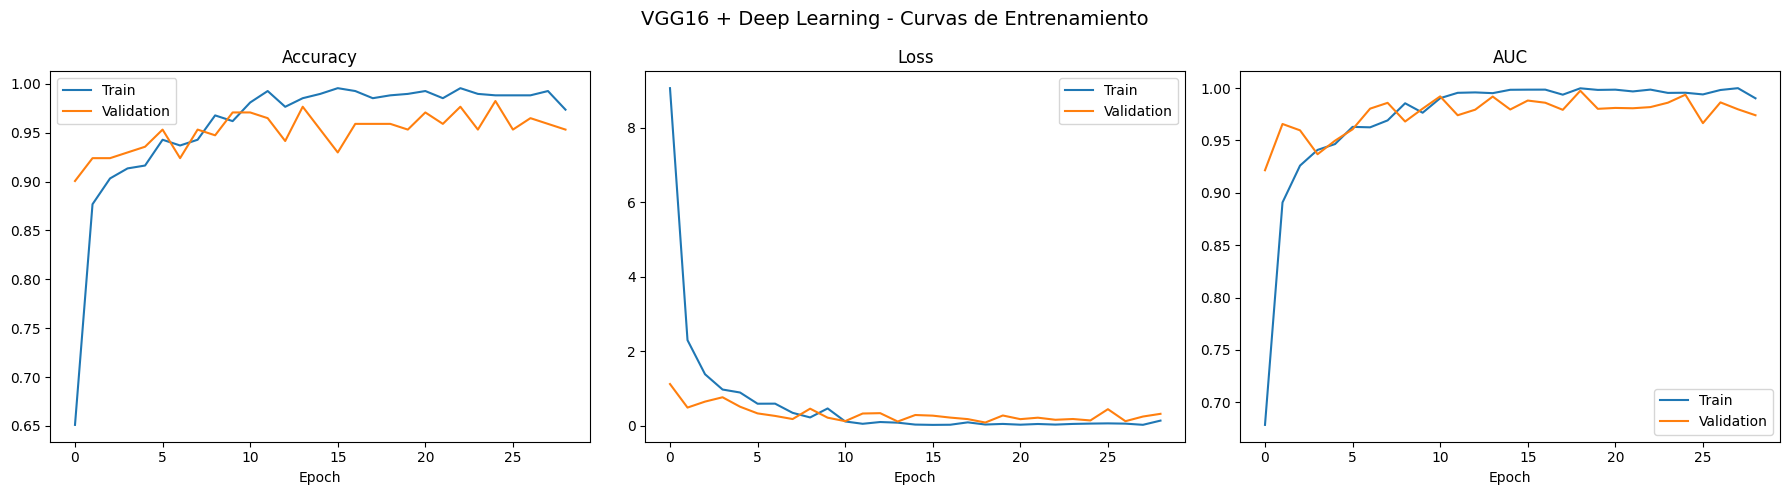

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("VGG16 + Deep Learning - Curvas de Entrenamiento", fontsize=14)

axes[0].plot(history_vgg_dl.history['accuracy'], label='Train')
axes[0].plot(history_vgg_dl.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_vgg_dl.history['loss'], label='Train')
axes[1].plot(history_vgg_dl.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_vgg_dl.history['auc'], label='Train')
axes[2].plot(history_vgg_dl.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Ensemble Learning

### 7.1 Load the previous models

In [42]:
# FFN
model_ffn_loaded = models.Sequential(name="Feed_Forward_Network")
model_ffn_loaded.add(layers.Flatten(input_shape=(SIZE, SIZE, 3)))
model_ffn_loaded.add(layers.Dense(256, activation='relu'))
model_ffn_loaded.add(layers.Dropout(0.3))
model_ffn_loaded.add(layers.Dense(128, activation='relu'))
model_ffn_loaded.add(layers.Dropout(0.3))
model_ffn_loaded.add(layers.Dense(64, activation='relu'))
model_ffn_loaded.add(layers.Dense(2, activation='softmax'))
model_ffn_loaded.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model_ffn_loaded.load_weights('M1_FNN.weights.h5')


# CNN
model_cnn_loaded = models.Sequential(name="CNN")
model_cnn_loaded.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(SIZE, SIZE, 3)))
model_cnn_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_loaded.add(layers.Dropout(0.2))
model_cnn_loaded.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_cnn_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_loaded.add(layers.Dropout(0.2))
model_cnn_loaded.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_cnn_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_loaded.add(layers.Dropout(0.2))
model_cnn_loaded.add(layers.Flatten())
model_cnn_loaded.add(layers.Dense(128, activation='relu'))
model_cnn_loaded.add(layers.Dropout(0.3))
model_cnn_loaded.add(layers.Dense(2, activation='softmax'))
model_cnn_loaded.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model_cnn_loaded.load_weights('M2_CNN.weights.h5')


# CNN + Augmentation
model_cnn_aug_loaded = models.Sequential(name="CNN_Aug")
model_cnn_aug_loaded.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(SIZE, SIZE, 3)))
model_cnn_aug_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug_loaded.add(layers.Dropout(0.2))
model_cnn_aug_loaded.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_cnn_aug_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug_loaded.add(layers.Dropout(0.2))
model_cnn_aug_loaded.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_cnn_aug_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug_loaded.add(layers.Dropout(0.2))
model_cnn_aug_loaded.add(layers.Flatten())
model_cnn_aug_loaded.add(layers.Dense(128, activation='relu'))
model_cnn_aug_loaded.add(layers.Dropout(0.3))
model_cnn_aug_loaded.add(layers.Dense(2, activation='softmax'))
model_cnn_aug_loaded.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model_cnn_aug_loaded.load_weights('M3_CNN_aug.weights.h5')


# VGG16 + RandomForest (Sklearn)
RF_model_loaded  = joblib.load('M4_vgg_rf.pkl')
VGG_model_loaded = joblib.load('M4_vgg_extractor.pkl')


# VGG16 + FNN
model_vgg_dl_loaded = models.Sequential(name="VGG16_FNN")
model_vgg_dl_loaded.add(layers.Dense(256, activation='relu', input_shape=(X_for_RF.shape[1],)))
model_vgg_dl_loaded.add(layers.Dropout(0.3))
model_vgg_dl_loaded.add(layers.Dense(128, activation='relu'))
model_vgg_dl_loaded.add(layers.Dropout(0.3))
model_vgg_dl_loaded.add(layers.Dense(64, activation='relu'))
model_vgg_dl_loaded.add(layers.Dropout(0.2))
model_vgg_dl_loaded.add(layers.Dense(2, activation='softmax'))
model_vgg_dl_loaded.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model_vgg_dl_loaded.load_weights('M5_vgg_FNN.weights.h5')

print("All models loaded")

/home/chickenux/Documents/celulas_clasificacion/ambientexd/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/chickenux/Documents/celulas_clasificacion/ambientexd/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/chickenux/Documents/celulas_clasificacion/ambientexd/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

All models loaded


/home/chickenux/Documents/celulas_clasificacion/ambientexd/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 7.2 Evualuate with VALIDATION data

In [51]:
# One-hot for Keras
y_val_cat     = to_categorical(y_val, num_classes=2)
y_val_vgg_cat = to_categorical(y_val_vgg, num_classes=2)

# Val predictions
pred_val_ffn     = model_ffn_loaded.predict(X_val)
pred_val_cnn     = model_cnn_loaded.predict(X_val)
pred_val_cnn_aug = model_cnn_aug_loaded.predict(X_val)
pred_val_vgg_rf  = RF_model_loaded.predict(X_val_RF)
pred_val_vgg_dl  = model_vgg_dl_loaded.predict(X_val_RF)

# Real labels
y_val_true     = np.argmax(y_val, axis=1)
y_val_true_vgg = y_val_vgg

# Labels predichos
pred_labels = {
    'Feed Forward' : np.argmax(pred_val_ffn, axis=1),
    'CNN'          : np.argmax(pred_val_cnn, axis=1),
    'CNN + Aug'    : np.argmax(pred_val_cnn_aug, axis=1),
    'VGG16 + RF'   : pred_val_vgg_rf,
    'VGG16 + DL'   : np.argmax(pred_val_vgg_dl, axis=1),
}

# Pro for class 1 AUC
pred_probas_val = {
    'Feed Forward' : pred_val_ffn[:, 1],
    'CNN'          : pred_val_cnn[:, 1],
    'CNN + Aug'    : pred_val_cnn_aug[:, 1],
    'VGG16 + RF'   : RF_model_loaded.predict_proba(X_val_RF)[:, 1],
    'VGG16 + DL'   : pred_val_vgg_dl[:, 1],
}

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


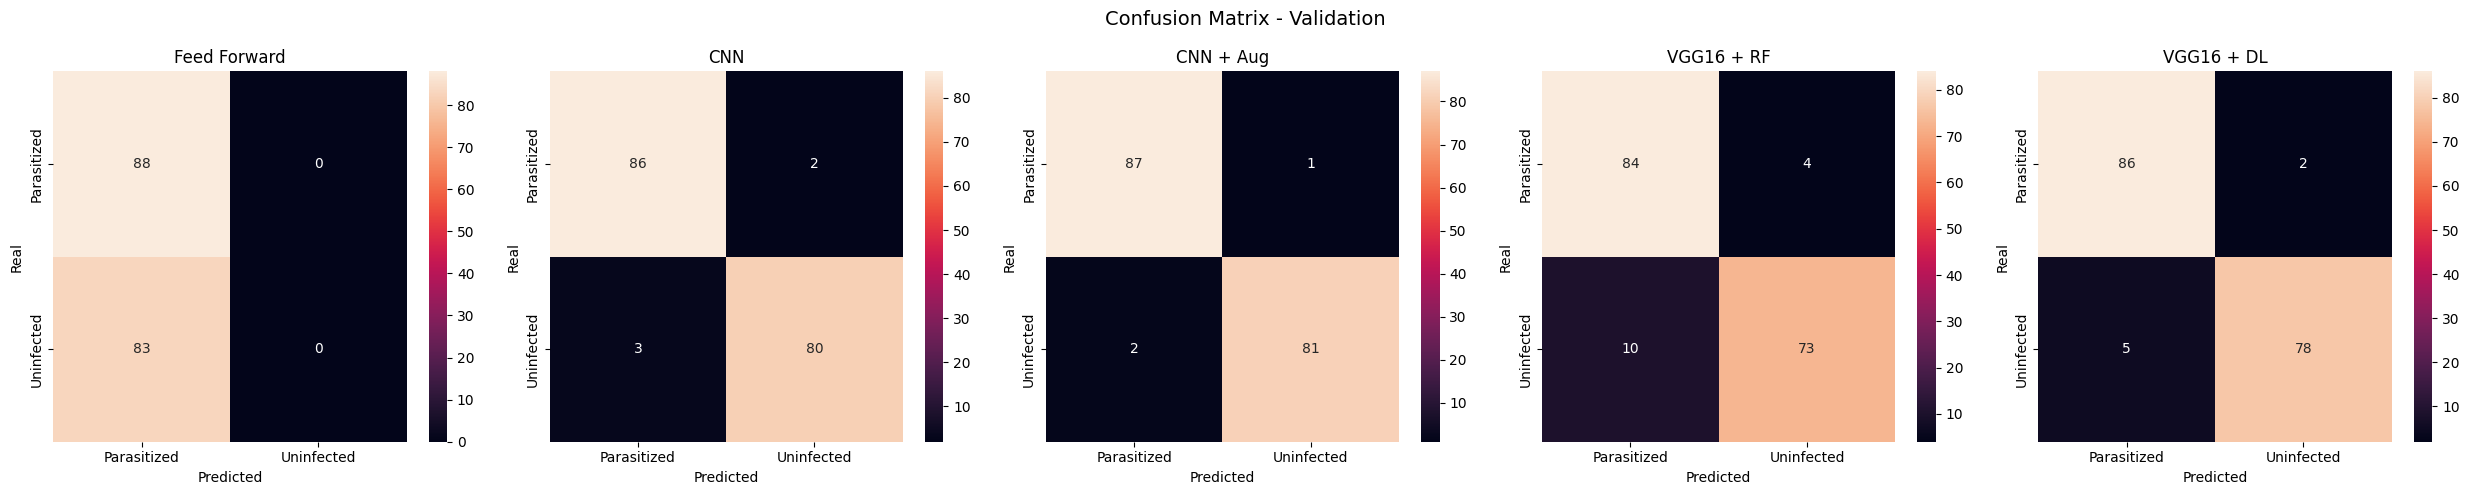

In [52]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle("Confusion Matrix - Validation", fontsize=14)

class_names = ['Parasitized', 'Uninfected']

for i, (nombre, preds) in enumerate(pred_labels.items()):
    y_true_actual = y_val_true_vgg if 'VGG' in nombre else y_val_true
    cm = confusion_matrix(y_true_actual, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                xticklabels=class_names,
                yticklabels=class_names)
    axes[i].set_title(nombre)
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [53]:
results_val = {}

for nombre, preds in pred_labels.items():
    y_true_actual  = y_val_true_vgg if 'VGG' in nombre else y_val_true
    probas_actual  = pred_probas_val[nombre]

    acc  = accuracy_score(y_true_actual, preds)
    prec = precision_score(y_true_actual, preds, zero_division=0)
    auc  = roc_auc_score(y_true_actual, probas_actual)

    results_val[nombre] = {'accuracy': acc, 'precision': prec, 'auc': auc}

# Orden by AUC
print(f"{'MODEL':<25} {'Accuracy':>10} {'Precision':>10} {'AUC':>10}")
print("-" * 55)
for nombre, m in sorted(results_val.items(), key=lambda x: x[1]['auc'], reverse=True):
    print(f"{nombre:<25} {m['accuracy']:>10.4f} {m['precision']:>10.4f} {m['auc']:>10.4f}")

# Top 3
top3 = sorted(results_val.items(), key=lambda x: x[1]['auc'], reverse=True)[:3]
top3_nombres = [nombre for nombre, _ in top3]

print(f"\nTop 3 to Ensemble:")
for nombre, m in top3:
    print(f"  - {nombre:<25} AUC={m['auc']:.4f}  Acc={m['accuracy']:.4f}")

MODEL                       Accuracy  Precision        AUC
-------------------------------------------------------
CNN + Aug                     0.9825     0.9878     0.9993
CNN                           0.9708     0.9756     0.9979
VGG16 + DL                    0.9591     0.9750     0.9975
VGG16 + RF                    0.9181     0.9481     0.9862
Feed Forward                  0.5146     0.0000     0.5000

Top 3 to Ensemble:
  - CNN + Aug                 AUC=0.9993  Acc=0.9825
  - CNN                       AUC=0.9979  Acc=0.9708
  - VGG16 + DL                AUC=0.9975  Acc=0.9591


### 7.3 Ensemble with the top 3 models

In [56]:
# Top 3: CNN+Aug, CNN, VGG16+DL
all_preds_val = np.array([pred_val_cnn_aug, pred_val_cnn, pred_val_vgg_dl])

best_auc = 0
best_weights = None

for w1 in range(0, 11):
    for w2 in range(0, 11):
        for w3 in range(0, 11):
            wts = [w/10.0 for w in [w1, w2, w3]]
            if round(sum(wts), 1) != 1.0:
                continue
            weighted = np.tensordot(all_preds_val, wts, axes=((0), (0)))
            auc = roc_auc_score(y_val_true, weighted[:, 1])
            if auc > best_auc:
                best_auc = auc
                best_weights = wts

print(f"Best Weights:")
print(f"  CNN + Aug : {best_weights[0]}")
print(f"  CNN       : {best_weights[1]}")
print(f"  VGG16 + DL: {best_weights[2]}")
print(f"AUC Ensemble in Validation: {best_auc:.4f}")

Best Weights:
  CNN + Aug : 0.5
  CNN       : 0.0
  VGG16 + DL: 0.5
AUC Ensemble in Validation: 0.9999


In [57]:
# Save best weights
with open('ensemble_weights.json', 'w') as f:
    json.dump(best_weights, f)
print("Saved !")

Saved !


## 8. Final Results and Comparasion

### 8.1 Load all the models

In [ ]:
# FFN
model_ffn_loaded = models.Sequential(name="Feed_Forward_Network")
model_ffn_loaded.add(layers.Flatten(input_shape=(SIZE, SIZE, 3)))
model_ffn_loaded.add(layers.Dense(256, activation='relu'))
model_ffn_loaded.add(layers.Dropout(0.3))
model_ffn_loaded.add(layers.Dense(128, activation='relu'))
model_ffn_loaded.add(layers.Dropout(0.3))
model_ffn_loaded.add(layers.Dense(64, activation='relu'))
model_ffn_loaded.add(layers.Dense(2, activation='softmax'))
model_ffn_loaded.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model_ffn_loaded.load_weights('M1_FNN.weights.h5')


# CNN
model_cnn_loaded = models.Sequential(name="CNN")
model_cnn_loaded.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(SIZE, SIZE, 3)))
model_cnn_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_loaded.add(layers.Dropout(0.2))
model_cnn_loaded.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_cnn_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_loaded.add(layers.Dropout(0.2))
model_cnn_loaded.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_cnn_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_loaded.add(layers.Dropout(0.2))
model_cnn_loaded.add(layers.Flatten())
model_cnn_loaded.add(layers.Dense(128, activation='relu'))
model_cnn_loaded.add(layers.Dropout(0.3))
model_cnn_loaded.add(layers.Dense(2, activation='softmax'))
model_cnn_loaded.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model_cnn_loaded.load_weights('M2_CNN.weights.h5')


# CNN + Augmentation
model_cnn_aug_loaded = models.Sequential(name="CNN_Aug")
model_cnn_aug_loaded.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(SIZE, SIZE, 3)))
model_cnn_aug_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug_loaded.add(layers.Dropout(0.2))
model_cnn_aug_loaded.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_cnn_aug_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug_loaded.add(layers.Dropout(0.2))
model_cnn_aug_loaded.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_cnn_aug_loaded.add(layers.MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug_loaded.add(layers.Dropout(0.2))
model_cnn_aug_loaded.add(layers.Flatten())
model_cnn_aug_loaded.add(layers.Dense(128, activation='relu'))
model_cnn_aug_loaded.add(layers.Dropout(0.3))
model_cnn_aug_loaded.add(layers.Dense(2, activation='softmax'))
model_cnn_aug_loaded.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model_cnn_aug_loaded.load_weights('M3_CNN_aug.weights.h5')


# VGG16 + RandomForest (Sklearn)
RF_model_loaded  = joblib.load('M4_vgg_rf.pkl')
VGG_model_loaded = joblib.load('M4_vgg_extractor.pkl')


# VGG16 + FNN
model_vgg_dl_loaded = models.Sequential(name="VGG16_FNN")
model_vgg_dl_loaded.add(layers.Dense(256, activation='relu', input_shape=(X_for_RF.shape[1],)))
model_vgg_dl_loaded.add(layers.Dropout(0.3))
model_vgg_dl_loaded.add(layers.Dense(128, activation='relu'))
model_vgg_dl_loaded.add(layers.Dropout(0.3))
model_vgg_dl_loaded.add(layers.Dense(64, activation='relu'))
model_vgg_dl_loaded.add(layers.Dropout(0.2))
model_vgg_dl_loaded.add(layers.Dense(2, activation='softmax'))
model_vgg_dl_loaded.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model_vgg_dl_loaded.load_weights('M5_vgg_FNN.weights.h5')

# Ensemble Model
with open('ensemble_weights.json', 'r') as f:
    best_weights = json.load(f)

print("All models loaded + Ensemble")

All models loaded + Ensemble


### 8.2 Verifying TEST dataset

In [ ]:
y_true_test     = np.argmax(y_test, axis=1)
y_true_test_vgg = y_test_vgg

results_test = {}

# Feed Forward
pred_ffn = model_ffn_loaded.predict(X_test)
results_test['Feed Forward'] = {
    'accuracy' : accuracy_score(y_true_test, np.argmax(pred_ffn, axis=1)),
    'precision': precision_score(y_true_test, np.argmax(pred_ffn, axis=1), zero_division=0),
    'auc'      : roc_auc_score(y_true_test, pred_ffn[:, 1])
}

# CNN
pred_cnn = model_cnn_loaded.predict(X_test)
results_test['CNN'] = {
    'accuracy' : accuracy_score(y_true_test, np.argmax(pred_cnn, axis=1)),
    'precision': precision_score(y_true_test, np.argmax(pred_cnn, axis=1), zero_division=0),
    'auc'      : roc_auc_score(y_true_test, pred_cnn[:, 1])
}

# CNN + Aug
pred_cnn_aug = model_cnn_aug_loaded.predict(X_test)
results_test['CNN + Aug'] = {
    'accuracy' : accuracy_score(y_true_test, np.argmax(pred_cnn_aug, axis=1)),
    'precision': precision_score(y_true_test, np.argmax(pred_cnn_aug, axis=1), zero_division=0),
    'auc'      : roc_auc_score(y_true_test, pred_cnn_aug[:, 1])
}

# VGG16 + RF
pred_proba_rf = RF_model_loaded.predict_proba(X_test_RF)
pred_label_rf = RF_model_loaded.predict(X_test_RF)
results_test['VGG16 + RF'] = {
    'accuracy' : accuracy_score(y_true_test_vgg, pred_label_rf),
    'precision': precision_score(y_true_test_vgg, pred_label_rf, zero_division=0),
    'auc'      : roc_auc_score(y_true_test_vgg, pred_proba_rf[:, 1])
}

# VGG16 + DL
pred_vgg_dl = model_vgg_dl_loaded.predict(X_test_RF)
results_test['VGG16 + DL'] = {
    'accuracy' : accuracy_score(y_true_test_vgg, np.argmax(pred_vgg_dl, axis=1)),
    'precision': precision_score(y_true_test_vgg, np.argmax(pred_vgg_dl, axis=1), zero_division=0),
    'auc'      : roc_auc_score(y_true_test_vgg, pred_vgg_dl[:, 1])
}

# Ensemble
all_preds_test = np.array([pred_cnn_aug, pred_cnn, pred_vgg_dl])
ensemble_pred  = np.tensordot(all_preds_test, best_weights, axes=((0), (0)))
results_test['Ensemble'] = {
    'accuracy' : accuracy_score(y_true_test, np.argmax(ensemble_pred, axis=1)),
    'precision': precision_score(y_true_test, np.argmax(ensemble_pred, axis=1), zero_division=0),
    'auc'      : roc_auc_score(y_true_test, ensemble_pred[:, 1])
}

# Table
print(f"{'MODEL':<25} {'Accuracy':>10} {'Precision':>10} {'AUC':>10}")
print("-" * 55)
for nombre, m in sorted(results_test.items(), key=lambda x: x[1]['auc'], reverse=True):
    print(f"{nombre:<25} {m['accuracy']:>10.4f} {m['precision']:>10.4f} {m['auc']:>10.4f}")

# Save
with open('results_test.json', 'w') as f:
    json.dump(results_test, f)
print("\nSaved results_test.json !")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
MODEL                       Accuracy  Precision        AUC
-------------------------------------------------------
Ensemble                      0.9579     0.9505     0.9932
VGG16 + RF                    0.9393     0.9579     0.9901
VGG16 + DL                    0.9439     0.9400     0.9900
CNN                           0.9533     0.9500     0.9872
CNN + Aug                     0.9486     0.9588     0.9868
Feed Forward                  0.5327     0.0000     0.5049

Saved results_test.json !


### 8.3 Results and Plot

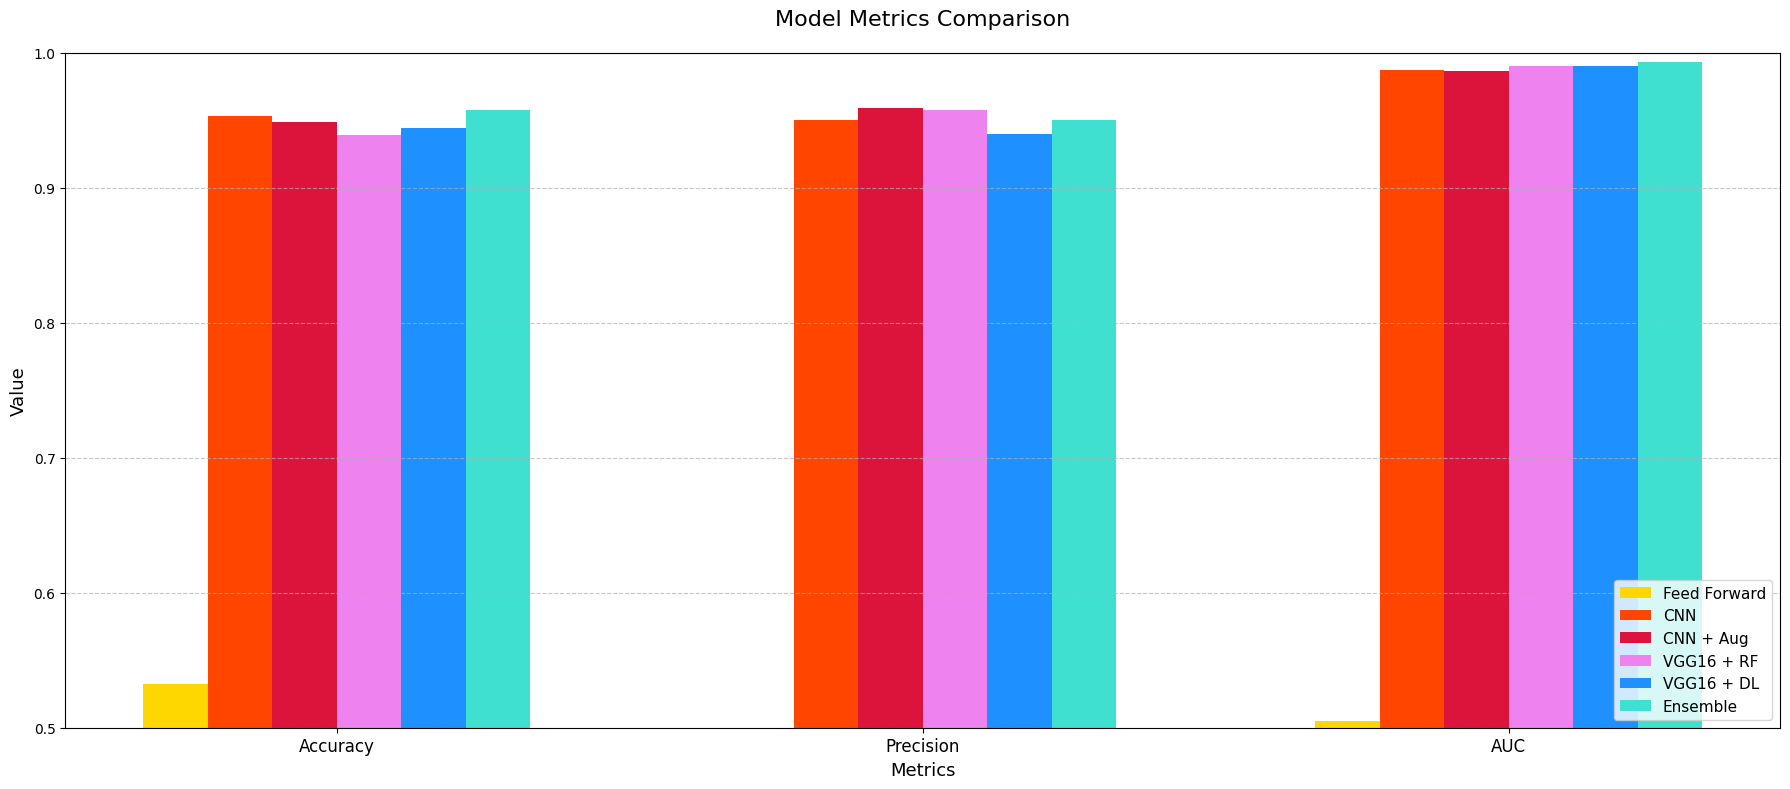

In [62]:
# Load Results
with open('results_test.json', 'r') as f:
    results = json.load(f)

# Plot
modelos = list(results.keys())
metricas = ['accuracy', 'precision', 'auc']
labels_metricas = ['Accuracy', 'Precision', 'AUC']
colores = ['gold', 'orangered', 'crimson', 'violet', 'dodgerblue', 'turquoise', 'limegreen']

x = np.arange(len(metricas))
width = 0.11

fig, ax = plt.subplots(figsize=(18, 8))

for i, (modelo, color) in enumerate(zip(modelos, colores)):
    valores = [results[modelo][m] for m in metricas]
    ax.bar(x + i * width, valores, width, label=modelo, color=color)

ax.set_title('Model Metrics Comparison', fontsize=16, pad=20)
ax.set_xlabel('Metrics', fontsize=13)
ax.set_ylabel('Value', fontsize=13)
ax.set_xticks(x + width * (len(modelos) - 1) / 2)
ax.set_xticklabels(labels_metricas, fontsize=12)
ax.set_ylim(0.50, 1.00)
ax.legend(fontsize=11, loc='lower right')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 8.4 Size of each model

In [64]:
modelos_archivos = {
    'Feed Forward'  : 'M1_FNN.weights.h5',
    'CNN'           : 'M2_CNN.weights.h5',
    'CNN + Aug'     : 'M3_CNN_aug.weights.h5',
    'VGG16 + RF'    : 'M4_vgg_rf.pkl',
    'VGG16 + DL'    : 'M5_vgg_FNN.weights.h5',
}

print(f"{'Model':<25} {'Size':>10}")
print("-" * 37)
sizes = {}
for nombre, archivo in modelos_archivos.items():
    if os.path.exists(archivo):
        size_mb = os.path.getsize(archivo) / (1024 * 1024)
        sizes[nombre] = size_mb
        print(f"{nombre:<25} {size_mb:>8.2f} MB")
    else:
        print(f"{nombre:<25} {'not found':>10}")

# Ensemble = suma de los 3 modelos del Top 3
ensemble_size = sizes['CNN + Aug'] + sizes['CNN'] + sizes['VGG16 + DL']
print("-" * 37)
print(f"{'Ensemble (Top 3)':<25} {ensemble_size:>8.2f} MB")

Model                           Size
-------------------------------------
Feed Forward                 36.51 MB
CNN                           7.87 MB
CNN + Aug                     7.87 MB
VGG16 + RF                    0.38 MB
VGG16 + DL                   74.01 MB
-------------------------------------
Ensemble (Top 3)             89.74 MB


### 8.5 Export CNN + Aug to TFLite

In [65]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_cnn_aug_loaded)
tflite_model = converter.convert()

with open('malaria_cnn_aug.tflite', 'wb') as f:
    f.write(tflite_model)

tflite_size = os.path.getsize('malaria_cnn_aug.tflite') / (1024 * 1024)
print(f"Model exported: malaria_cnn_aug.tflite")
print(f"Original size : 7.87 MB")
print(f"TFLite size   : {tflite_size:.2f} MB")
print(f"Reduction     : {(1 - tflite_size/7.87)*100:.1f}%")

INFO:tensorflow:Assets written to: /tmp/tmppbg79ftz/assets


INFO:tensorflow:Assets written to: /tmp/tmppbg79ftz/assets


Saved artifact at '/tmp/tmppbg79ftz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor_1696')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140354645903888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354645917136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354645917520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354645915024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354645913104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354645915216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354645908496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354645910992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354645909264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140354645911376: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model exporte

W0000 00:00:1776247414.389439  137917 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776247414.389456  137917 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1776247414.389781  137917 reader.cc:83] Reading SavedModel from: /tmp/tmppbg79ftz
I0000 00:00:1776247414.390493  137917 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1776247414.390501  137917 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmppbg79ftz
I0000 00:00:1776247414.397502  137917 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1776247414.398508  137917 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1776247414.441538  137917 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmppbg79ftz
I0000 00:00:1776247414.453909  137917 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 64137 microseconds.
I0000 00:00:1776247414.483035  137917